# Кластеризация. Wine dataset

Размер датасета: (178, 14)

Первые строки:
   class  Alcohol  Malic acid   Ash  Alcalinity of ash  Magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   

   Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color intensity   Hue  OD280/OD315 of diluted wines  Proline  
0             5.64  1.04                         

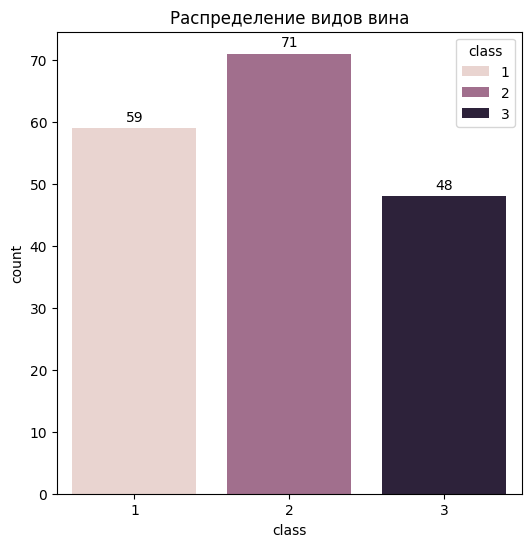

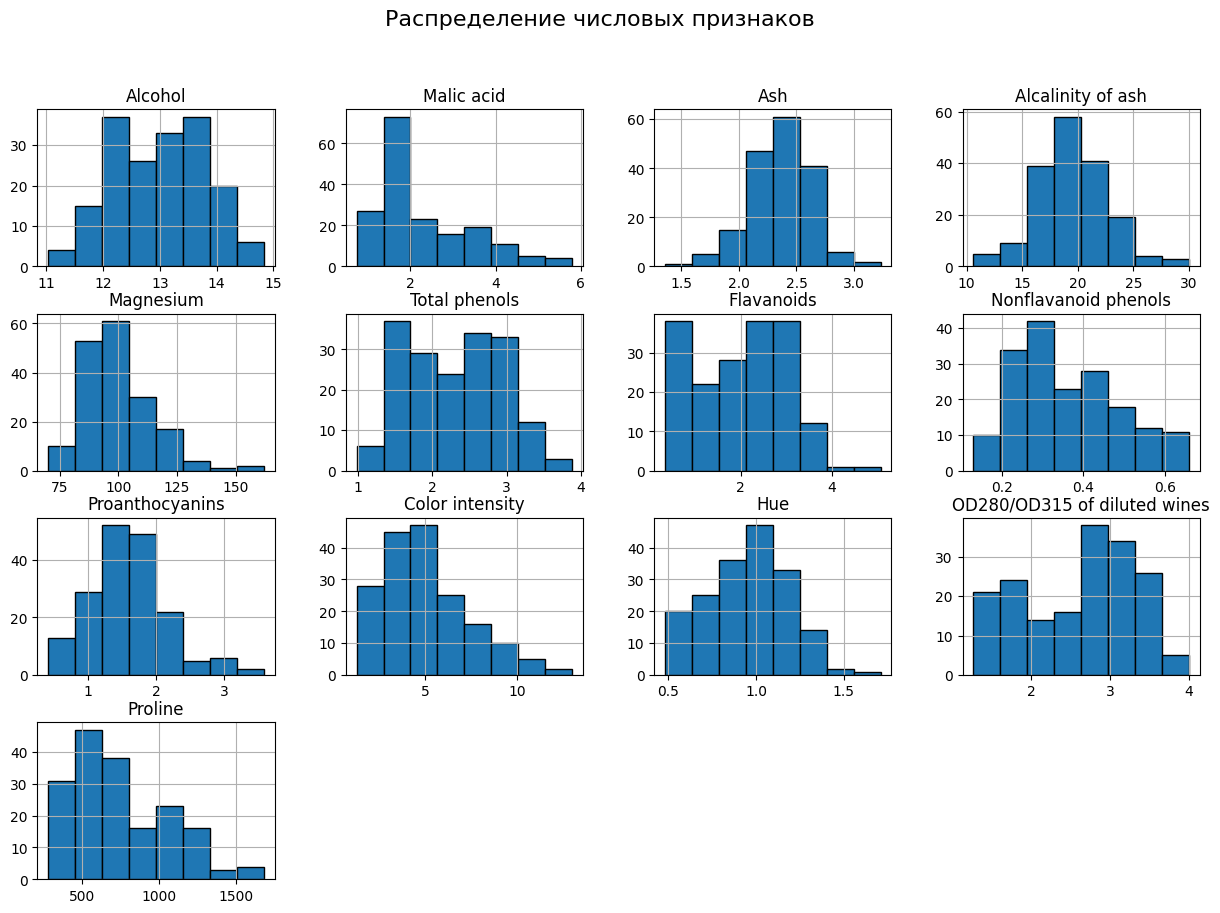

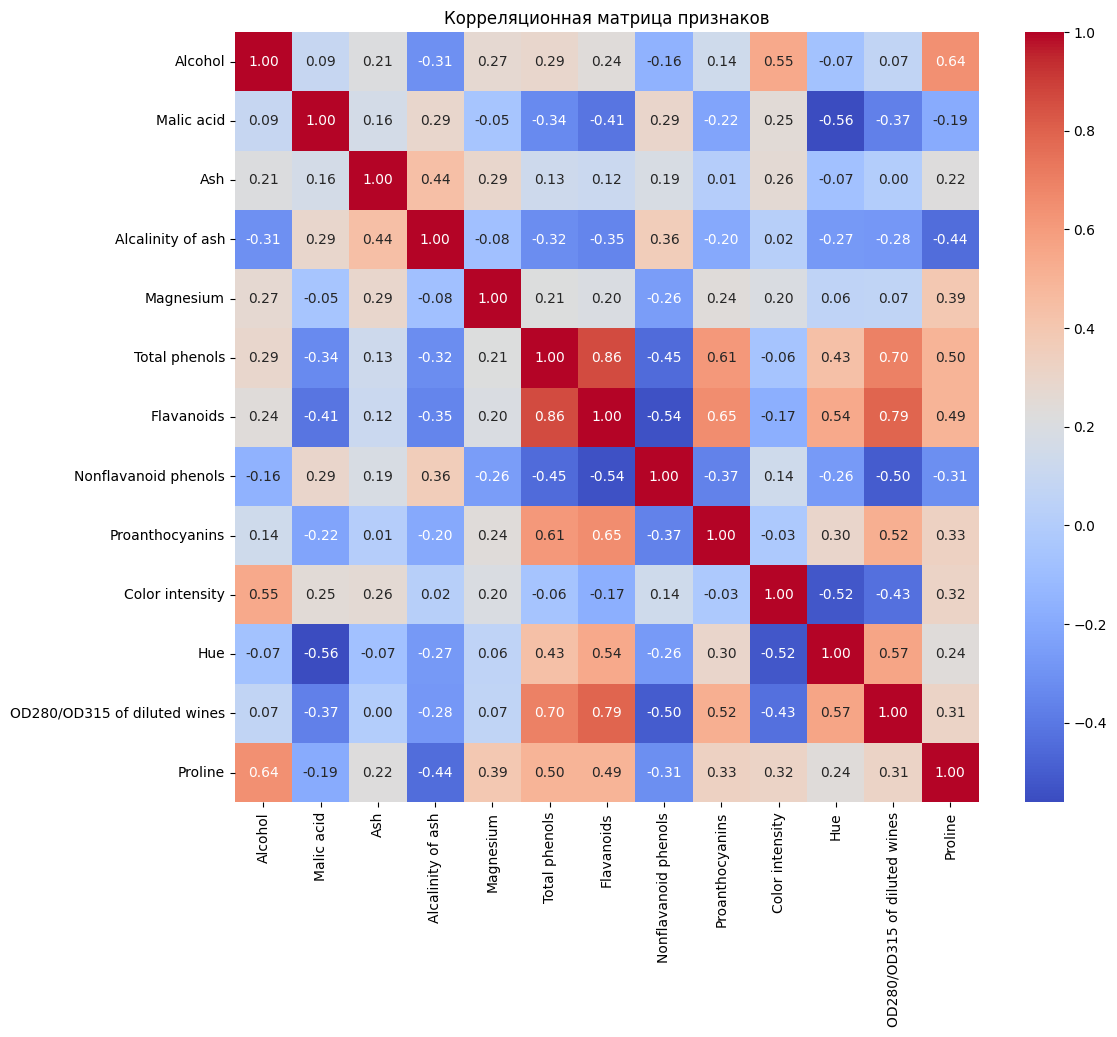

In [126]:
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, normaltest
import seaborn as sns

# Загрузка данных
df = pd.read_csv('Wine dataset.csv')
df = df.fillna(df.mean(numeric_only=True))

# Описание и базовый анализ
num_cols = df.columns.drop('class')

print("Размер датасета:", df.shape)
print("\nПервые строки:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nОписание признаков:")
print(df.describe().T)
print("\nКоличество пропусков:")
print(df.isnull().sum())

# Асимметрия и эксцесс
param_data = {'Параметр': [], 'Асимметрия': [], 'Эксцесс': []}
for col in num_cols:
    param_data['Параметр'].append(col)
    param_data['Асимметрия'].append(skew(df[col].dropna()))
    param_data['Эксцесс'].append(kurtosis(df[col].dropna()))
summary_df = pd.DataFrame(param_data)
print(summary_df)

# Нормальность распределения (тест Д’Агостино-Пирсона)
print("\nПроверка нормальности распределения:")
for col in num_cols:
    stat, p = normaltest(df[col].dropna())
    print(f"{col}: статистика={stat:.4f}, p-значение={p:.4f}")
    if p > 0.05:
        print(" → распределение близко к нормальному\n")
    else:
        print(" → распределение отличается от нормального\n")

# График распределения значений stress_level
plt.figure(figsize=(6, 6))
ax = sns.countplot(x="class", hue='class', data=df)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.title("Распределение видов вина")
plt.show()

# Гистограммы для числовых признаков
count_of_bins = int(1 + 3.322*math.log10(df.shape[0]))
df[num_cols].hist(bins=count_of_bins, figsize=(15, 10), edgecolor="black")
plt.suptitle("Распределение числовых признаков", fontsize=16)
plt.show()

# Корреляционный анализ
plt.figure(figsize=(12, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

In [134]:
import numpy as np

corr_matrix = df[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.6)]
print("Признаки для удаления из-за высокой парной корреляции (> 0.6):", to_drop)

df_reduced = df.drop(columns=to_drop)
num_cols = num_cols.drop(to_drop)

Признаки для удаления из-за высокой парной корреляции (> 0.6): ['Flavanoids', 'Proanthocyanins', 'OD280/OD315 of diluted wines', 'Proline']


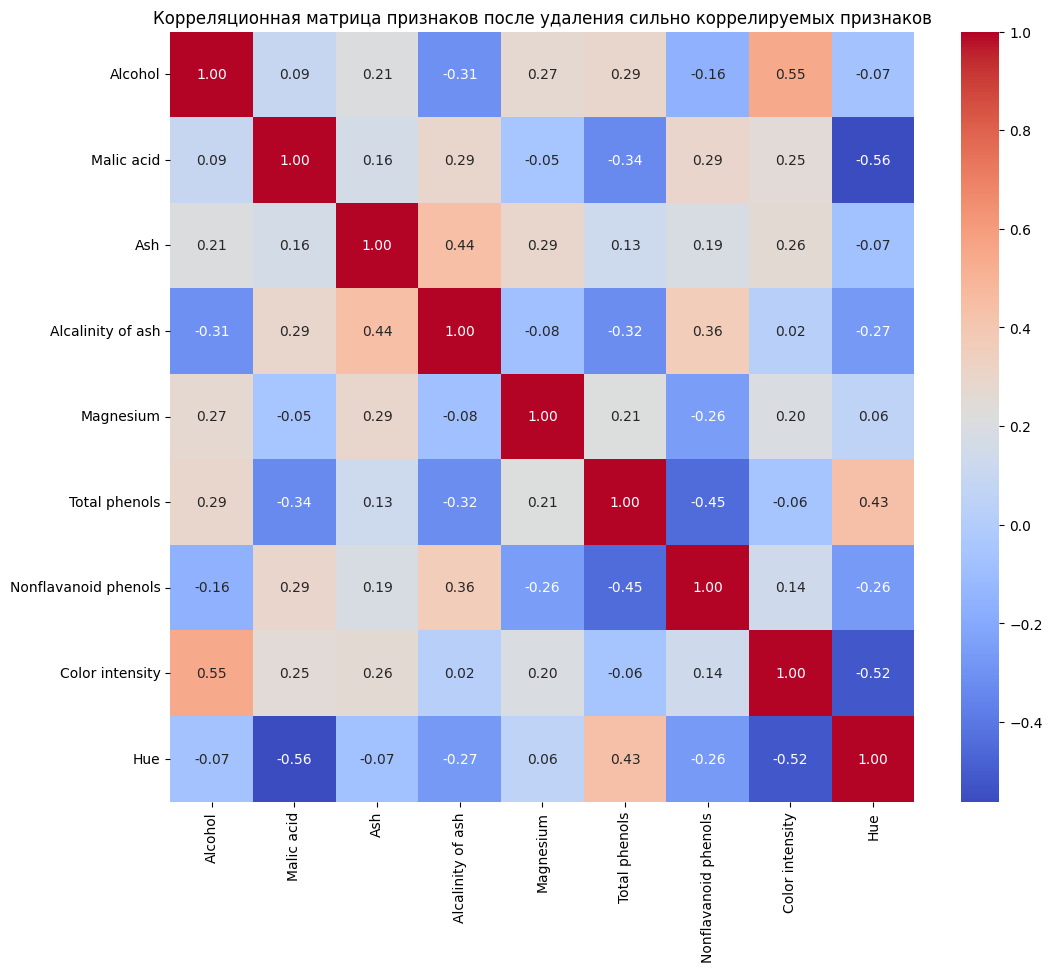

In [137]:
# Корреляционный анализ
plt.figure(figsize=(12, 10))
corr = df_reduced[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков после удаления сильно коррелируемых признаков')
plt.show()

In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df_reduced.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

# Проверим первые строки стандартизированного датасета и описательные статистики
scaled_head = df_scaled.head()
scaled_stats = df_scaled[num_cols].describe()
scaled_head, scaled_stats

(   class   Alcohol  Malic acid       Ash  Alcalinity of ash  Magnesium  \
 0      1  1.518613   -0.562250  0.232053          -1.169593   1.913905   
 1      1  0.246290   -0.499413 -0.827996          -2.490847   0.018145   
 2      1  0.196879    0.021231  1.109334          -0.268738   0.088358   
 3      1  1.691550   -0.346811  0.487926          -0.809251   0.930918   
 4      1  0.295700    0.227694  1.840403           0.451946   1.281985   
 
    Total phenols  Nonflavanoid phenols  Color intensity       Hue  
 0       0.808997             -0.659563         0.251717  0.362177  
 1       0.568648             -0.820719        -0.293321  0.406051  
 2       0.808997             -0.498407         0.269020  0.318304  
 3       2.491446             -0.981875         1.186068 -0.427544  
 4       0.808997              0.226796        -0.319276  0.362177  ,
             Alcohol    Malic acid           Ash  Alcalinity of ash  \
 count  1.780000e+02  1.780000e+02  1.780000e+02       1.78000

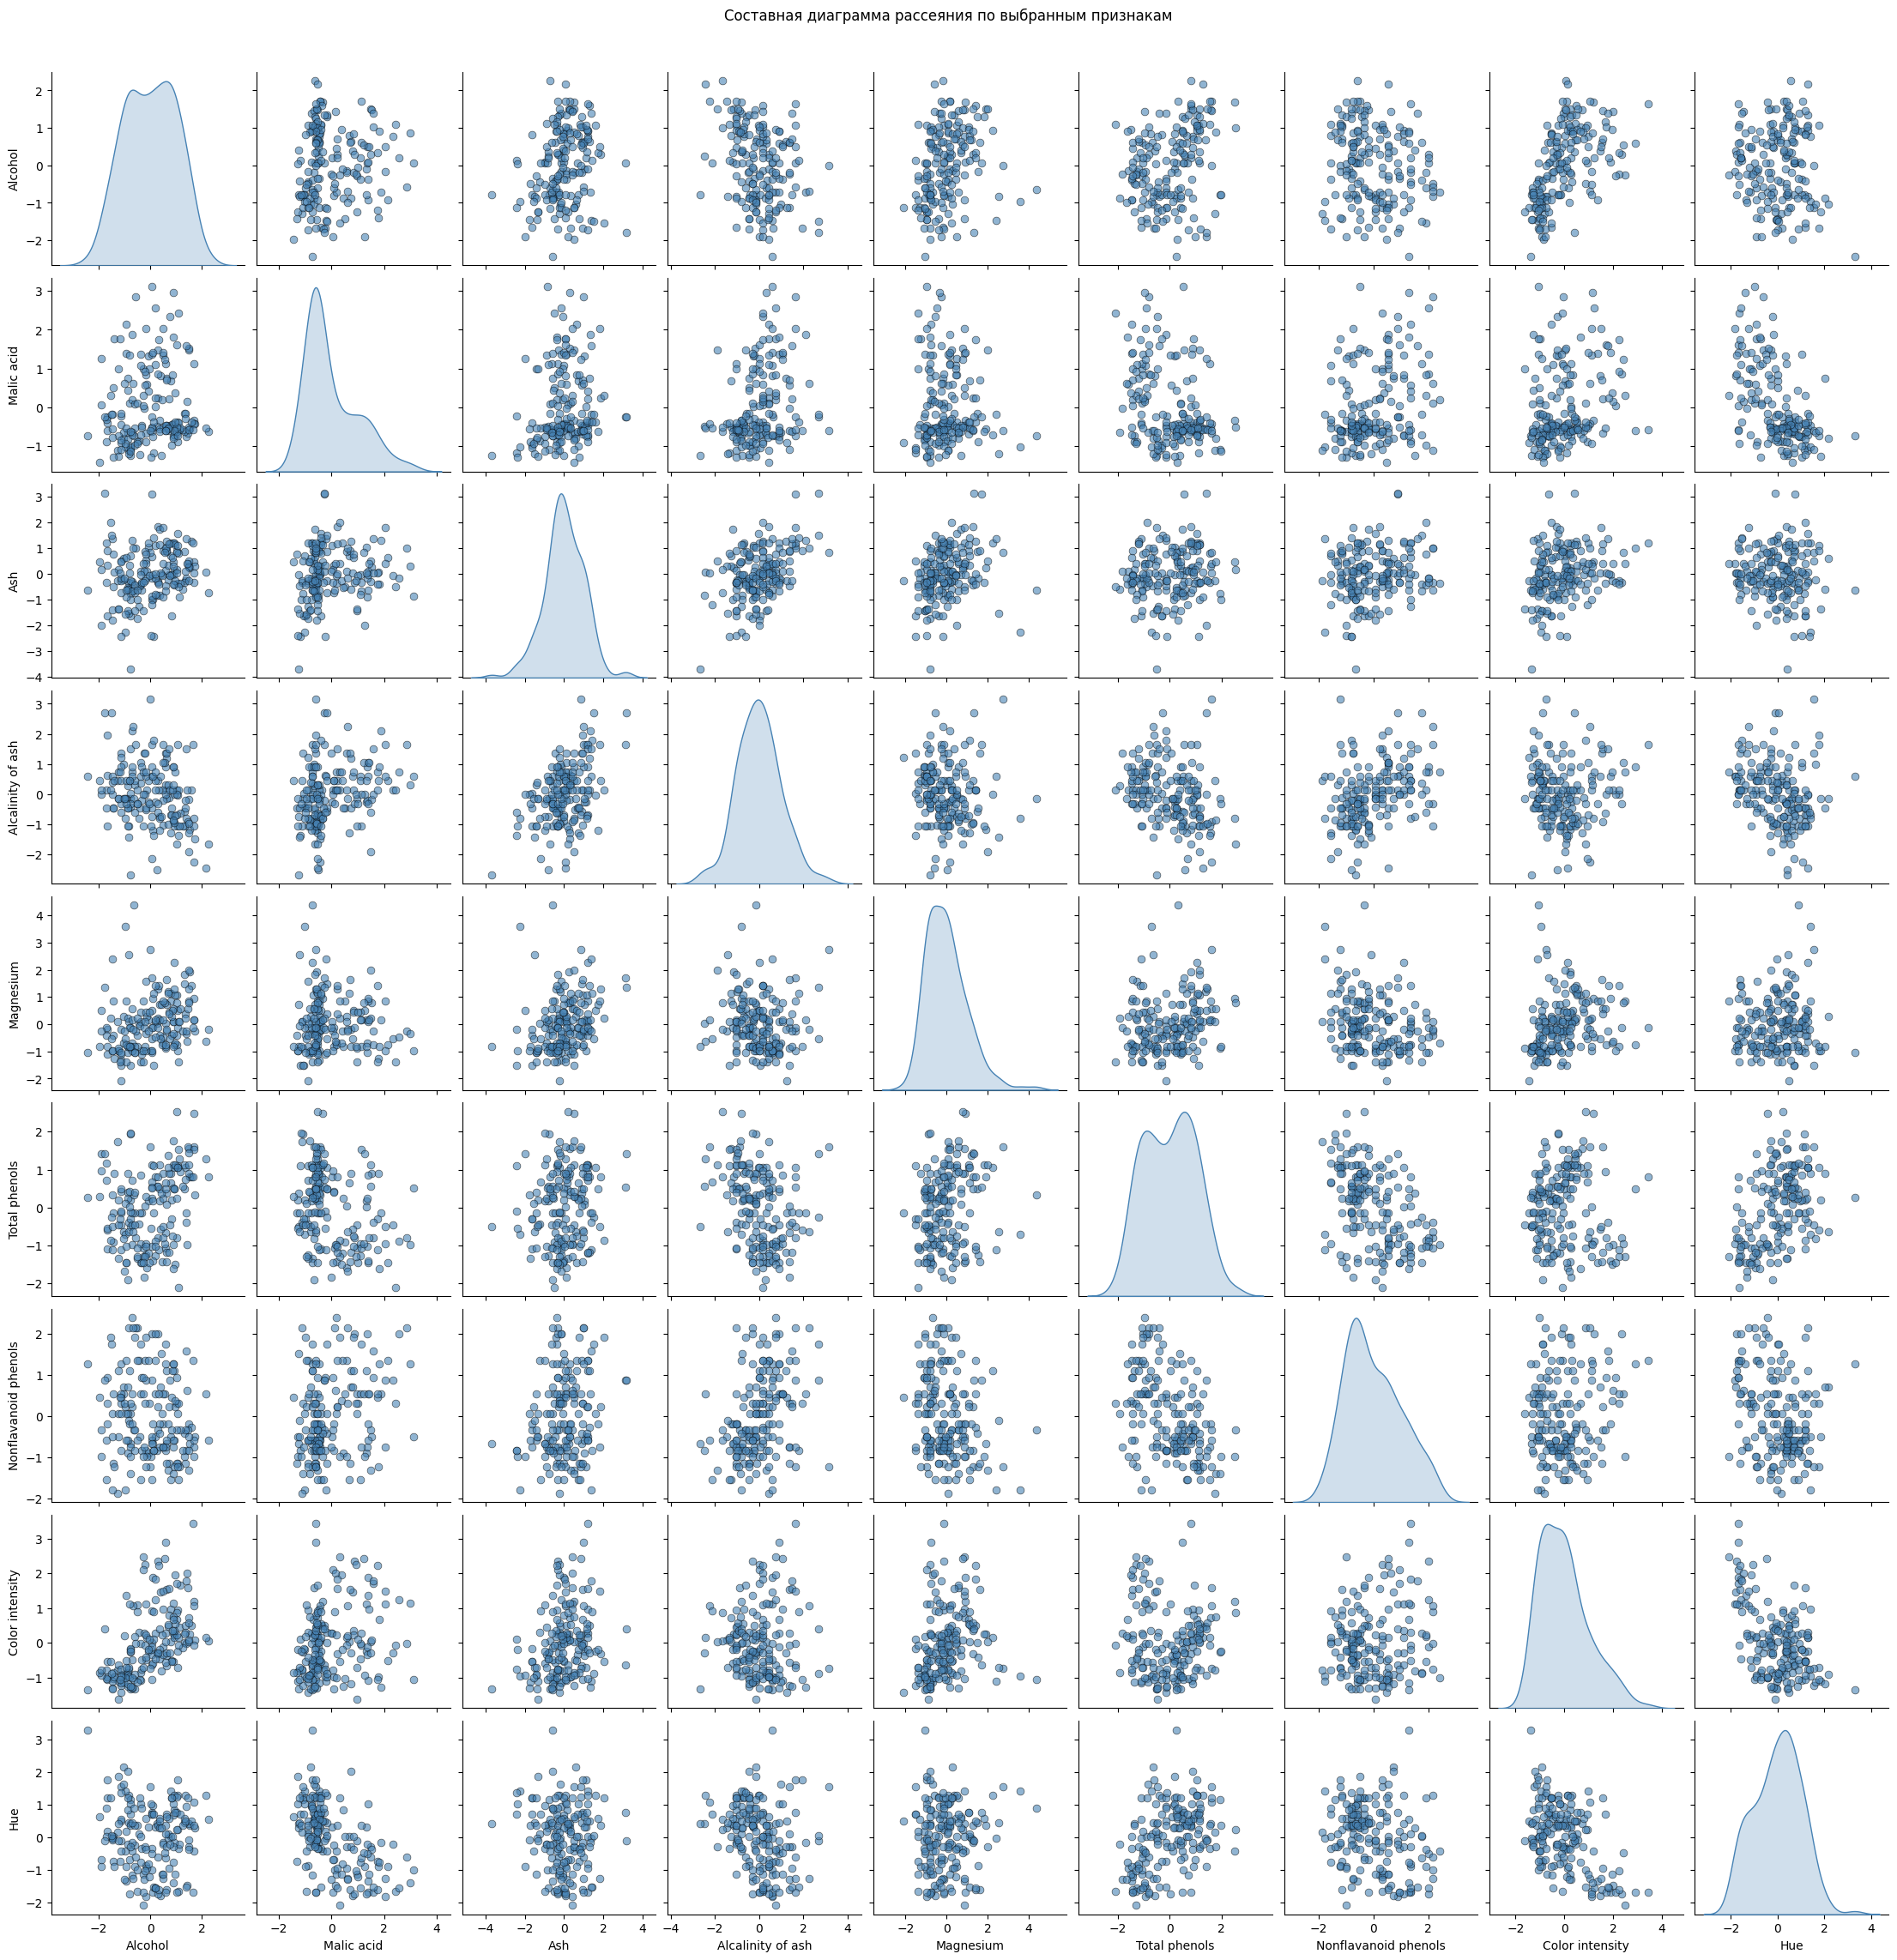

In [142]:
df_pairplot = df_scaled.drop(columns='class')

sns.pairplot(
    df_pairplot,
    diag_kind='kde',
    plot_kws={'color': 'steelblue', 'alpha': 0.6, 's': 40, 'edgecolor': 'k'},
    diag_kws={'color': 'steelblue'}
)
plt.suptitle("Составная диаграмма рассеяния по выбранным признакам", y=1.02)
plt.show()

Графики плохо читаемы и предположить разделение по классам тяжело, так как явной кластеризации точек не обнаруживается.

Применим метод главных компонент для снижения размерности данных и выявления скрытых латентных факторов.

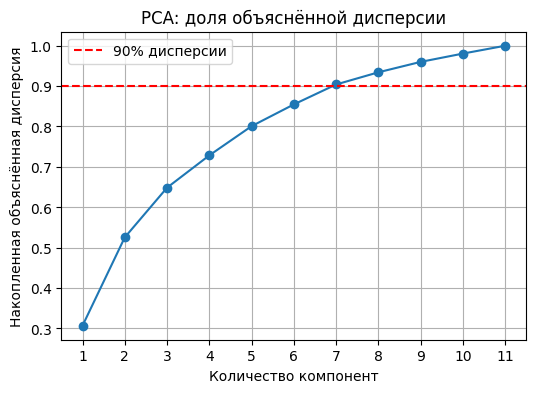

Количество компонент для 90% объяснённой дисперсии: 7

Матрица факторных нагрузок:
                        PC1    PC2    PC3    PC4    PC5    PC6    PC7
Alcohol               0.471  0.683 -0.272 -0.195 -0.113  0.150 -0.088
Malic acid           -0.512  0.486 -0.082  0.371 -0.147  0.537  0.180
Ash                  -0.006  0.557  0.719 -0.212 -0.029  0.114 -0.151
Alcalinity of ash    -0.605  0.143  0.651  0.113 -0.050 -0.099 -0.211
Magnesium             0.430  0.392  0.279  0.182  0.669 -0.043  0.298
Total phenols         0.800 -0.025  0.232  0.109 -0.335  0.049 -0.070
Nonflavanoid phenols -0.646  0.176  0.118 -0.443 -0.253 -0.121  0.501
Proanthocyanins       0.649 -0.047  0.244  0.457 -0.363 -0.210  0.278
Color intensity      -0.001  0.836 -0.235 -0.010 -0.082 -0.395 -0.067
Hue                   0.560 -0.558  0.272 -0.368  0.004  0.179  0.107
Proline               0.751  0.434 -0.075 -0.257 -0.002  0.107  0.021


In [119]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = df_scaled[selected_features]

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker="o")
plt.xlabel("Количество компонент")
plt.ylabel("Накопленная объяснённая дисперсия")
plt.title("PCA: доля объяснённой дисперсии")
plt.axhline(0.9, color='red', linestyle='--', label='90% дисперсии')
plt.xticks(range(1, len(explained_variance)+1))
plt.grid()
plt.legend()
plt.show()

pca = PCA(n_components=0.9) 
X_pca = pca.fit_transform(X_scaled)

print(f"Количество компонент для 90% объяснённой дисперсии: {pca.n_components_}")

# --- 4. Матрица факторных нагрузок ---
# Факторные нагрузки = коэффициенты PCA * sqrt(собственных значений)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

factor_loadings = pd.DataFrame(
    loadings,
    index=selected_features,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print("\nМатрица факторных нагрузок:")
print(factor_loadings.round(3))


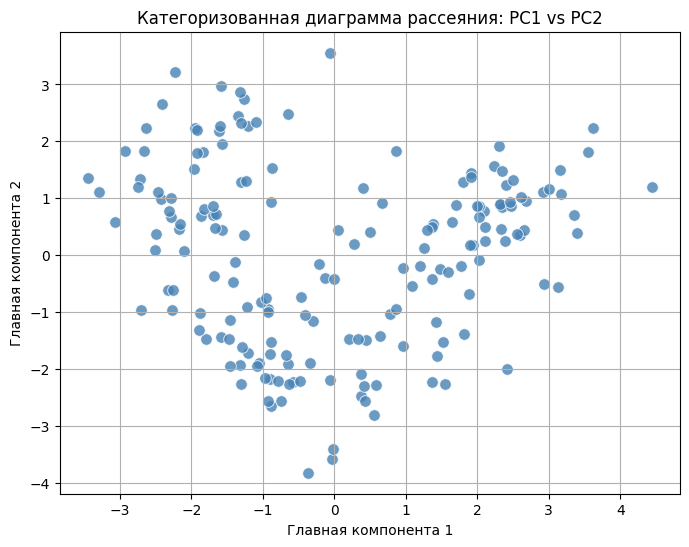

In [120]:
# --- 3. Формируем датафрейм с главными компонентами ---
pca_cols = [f"PC{i+1}" for i in range(pca.n_components_)]
df_pca = pd.DataFrame(X_pca, columns=pca_cols)
if 'class' in df.columns:
    df_pca['class'] = df['class']

# --- 5. Отдельные категоризованные scatter-графики для первых компонент ---
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_pca,
    x='PC1', y='PC2',
    color='steelblue',
    s=70, alpha=0.8
)
plt.title("Категоризованная диаграмма рассеяния: PC1 vs PC2")
plt.xlabel("Главная компонента 1")
plt.ylabel("Главная компонента 2")
plt.grid(True)
plt.show()